# Non-parametric Distributions

A distributional family restricts the possible shape of a population. Non-parametric methods describe its distribution without choosing that family first. They still depend on a finite sample and on choices such as the smoothing bandwidth.

I use simulations from known populations throughout. Observations are iid, which makes it possible to compare each estimate with its population target. No financial dataset is used here.

In [1]:
from pathlib import Path
import sys
repository = Path.cwd()
if not (repository / "src" / "finstats").is_dir():
    repository = repository.parent
if not (repository / "src" / "finstats").is_dir():
    raise RuntimeError("Run from the repository root or notebooks directory")
sys.path.insert(0, str(repository / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display
from finstats.descriptive import (
    sample_mean, sample_variance, sample_standard_deviation,
    sample_skewness, sample_kurtosis,
)
plt.rcParams.update({
    "figure.figsize": (7,4), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "font.size": 11, "axes.titlesize": 12,
    "legend.frameon": False, "lines.linewidth": 1.8,
})
from finstats.nonparametric import empirical_cdf, empirical_quantile, qq_data

## 1. From a population to an observed sample

The population CDF $F(x)=P(X\le x)$ and density $f(x)$ describe uncertainty before observation. The values $x_1,\ldots,x_n$ form one finite realization. Even when its population is fixed, another realization will have a different shape.

For illustration, I compare iid samples of size 100 from $N(0,1)$ and a unit-variance Student-$t_5$, with seed 401. Equal population mean and variance leave tail shape as the main difference. The histograms summarize the samples, while the curves show their known densities.

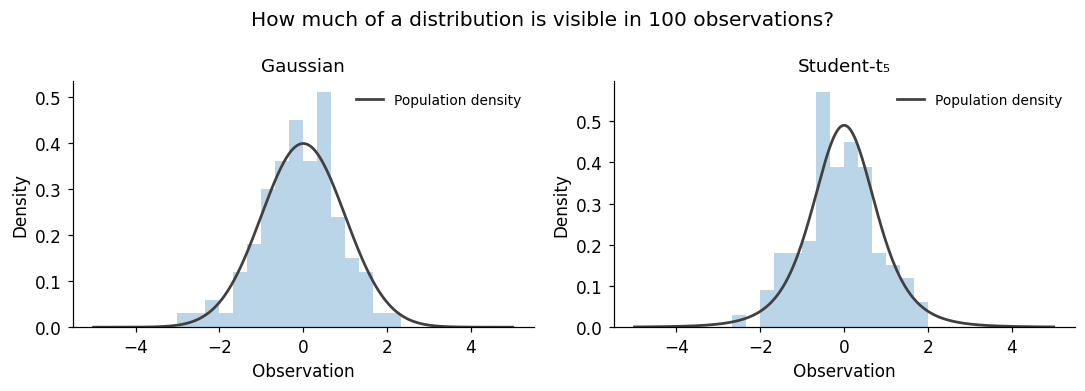

In [2]:
rng_samples = np.random.default_rng(401)
populations = {"Gaussian": stats.norm(), "Student-t₅": stats.t(5, scale=np.sqrt(3/5))}
samples = {name: distribution.rvs(size=100, random_state=rng_samples)
           for name, distribution in populations.items()}
grid = np.linspace(-5, 5, 801)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), sharex=True)
for ax, (name, distribution) in zip(axes, populations.items()):
    ax.hist(samples[name], bins=np.linspace(-5, 5, 31), weights=np.full(100, 3/100), alpha=.3)
    ax.plot(grid, distribution.pdf(grid), color="0.25", label="Population density")
    ax.set(xlabel="Observation", ylabel="Density", title=name)
    ax.legend(fontsize=9)
fig.suptitle("How much of a distribution is visible in 100 observations?")
fig.tight_layout()
plt.show()

## 2. Empirical cumulative distribution

The empirical CDF (ECDF) counts the fraction of observations at or below a threshold:
$$\hat F_n(x)=\frac1n\sum_{i=1}^n I(X_i\le x).$$
It is right-continuous, increases by $1/n$ at each distinct observation, and combines jumps when values are tied. The population can be continuous even though its empirical distribution places mass on the observed values.

At a fixed $x$, the indicators have success probability $F(x)$. Under iid sampling,
$$E[\hat F_n(x)]=F(x),\qquad
\operatorname{Var}[\hat F_n(x)]=\frac{F(x)(1-F(x))}{n}.$$
The expectation identifies the target, while the variance describes sampling uncertainty. Chebyshev's inequality gives
$$P(|\hat F_n(x)-F(x)|\ge\varepsilon)
\le\frac{F(x)(1-F(x))}{n\varepsilon^2}\longrightarrow0.$$
This is pointwise consistency. It does not require the observations themselves to have a finite mean, because the indicators are bounded.

For illustration, I retain the course's Cauchy example with $n=5,100,1000$. The samples are prefixes of one iid $t_1$ realization using seed 0. The plotting window is held fixed, with full sample ranges printed separately.

n=5: full sample range -5.015 to 5.379
n=100: full sample range -135.080 to 81.215
n=1000: full sample range -808.531 to 234.208


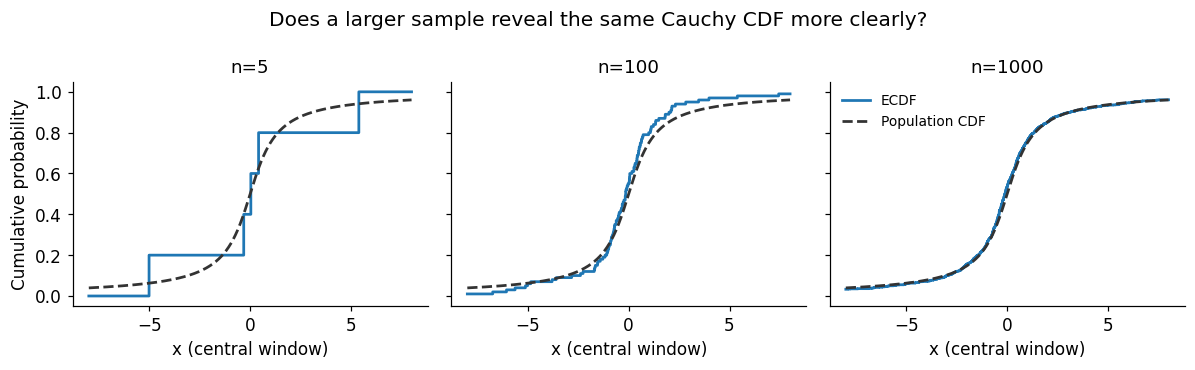

ECDF(0) expectation: population .5, replication average 0.4987
ECDF(0) variance: population .0025, replication variance 0.002574


In [3]:
cauchy_sample = np.random.default_rng(0).standard_t(1, size=1000)
cdf_grid = np.linspace(-8, 8, 1501)
fig, axes = plt.subplots(1, 3, figsize=(11, 3.4), sharex=True, sharey=True)
for ax, n in zip(axes, (5, 100, 1000)):
    values = cauchy_sample[:n]
    ax.step(cdf_grid, empirical_cdf(values)(cdf_grid), where="post", label="ECDF")
    ax.plot(cdf_grid, stats.t.cdf(cdf_grid, 1), "--", color="0.2", label="Population CDF")
    ax.set(xlabel="x (central window)", title=f"n={n}")
    print(f"n={n}: full sample range {values.min():.3f} to {values.max():.3f}")
axes[0].set_ylabel("Cumulative probability")
axes[-1].legend(fontsize=9)
fig.suptitle("Does a larger sample reveal the same Cauchy CDF more clearly?")
fig.tight_layout()
plt.show()
replicated = np.random.default_rng(404).standard_t(1, size=(2000, 100))
ecdf_at_zero = np.array([float(empirical_cdf(row)(0)) for row in replicated])
print(f"ECDF(0) expectation: population .5, replication average {ecdf_at_zero.mean():.4f}")
print(f"ECDF(0) variance: population .0025, replication variance {ecdf_at_zero.var():.6f}")

The Cauchy population has no mean, yet its ECDF can estimate probabilities consistently. The large observed extremes affect the sample range without invalidating the bounded-indicator argument.

## 3. Empirical quantiles

A population quantile $x_q=F^{-1}(q)$ is estimated by the inverse ECDF:
$$\hat x_q=\inf\{x:\hat F_n(x)\ge q\}=X_{(\lceil nq\rceil)},\qquad0<q<1.$$
Here $X_{(j)}$ is the $j$th ordered observation. This convention does not interpolate between observations. The endpoints return the sample minimum and maximum.

Under iid sampling, a unique quantile and a positive continuous density there give consistency. With the usual regularity conditions,
$$\sqrt n(\hat x_q-x_q)\xrightarrow{d}
N\left(0,\frac{q(1-q)}{f(x_q)^2}\right).$$
A low density at the target can make a quantile difficult to estimate, particularly in the tails.

For illustration, I reuse the Cauchy prefixes and estimate the 75th percentile, whose population value is one. The ECDF jump determines the realized estimate.

n=5: population quantile=1.000, estimate=0.412
n=100: population quantile=1.000, estimate=0.573
n=1000: population quantile=1.000, estimate=0.906


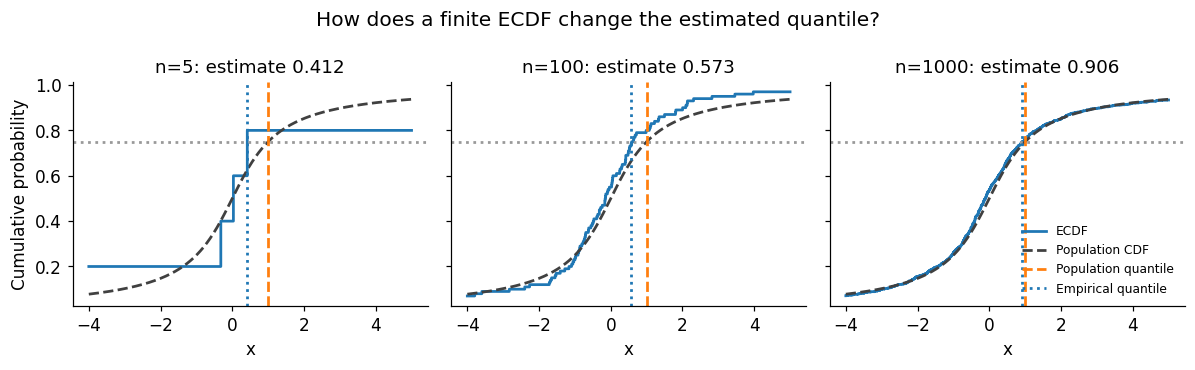

In [4]:
q = .75
true_quantile = stats.t.ppf(q, 1)
fig, axes = plt.subplots(1, 3, figsize=(11, 3.4), sharey=True)
quantile_grid = np.linspace(-4, 5, 1001)
for ax, n in zip(axes, (5, 100, 1000)):
    estimate = empirical_quantile(cauchy_sample[:n], q)
    ax.step(quantile_grid, empirical_cdf(cauchy_sample[:n])(quantile_grid), where="post", label="ECDF")
    ax.plot(quantile_grid, stats.t.cdf(quantile_grid, 1), "--", color="0.25", label="Population CDF")
    ax.axhline(q, color="0.6", linestyle=":")
    ax.axvline(true_quantile, color="C1", linestyle="--", label="Population quantile")
    ax.axvline(estimate, color="C0", linestyle=":", label="Empirical quantile")
    ax.set(xlabel="x", title=f"n={n}: estimate {estimate:.3f}")
    print(f"n={n}: population quantile={true_quantile:.3f}, estimate={estimate:.3f}")
axes[0].set_ylabel("Cumulative probability")
axes[-1].legend(fontsize=8, loc="lower right")
fig.suptitle("How does a finite ECDF change the estimated quantile?")
fig.tight_layout()
plt.show()

### Quantile precision

For illustration, I generate 500 independent samples of size 250 from each of the two unit-variance populations in Section 1, using seed 405. The table compares empirical 50th, 95th, and 99th percentiles with their population targets. The figure shows replication errors for the 99th percentile. These ranges describe the simulation replications, rather than confidence intervals for an observed sample.

,population,q,true quantile,mean estimate,replication SD
0,Gaussian,0.50,0.0000,-0.0078,0.0802
1,Gaussian,0.95,1.6449,1.6423,0.1362
2,Gaussian,0.99,2.3263,2.3221,0.2351
3,Student-t₅,0.50,0.0000,-0.0065,0.0643
4,Student-t₅,0.95,1.5608,1.5711,0.1768
5,Student-t₅,0.99,2.6065,2.5987,0.4538


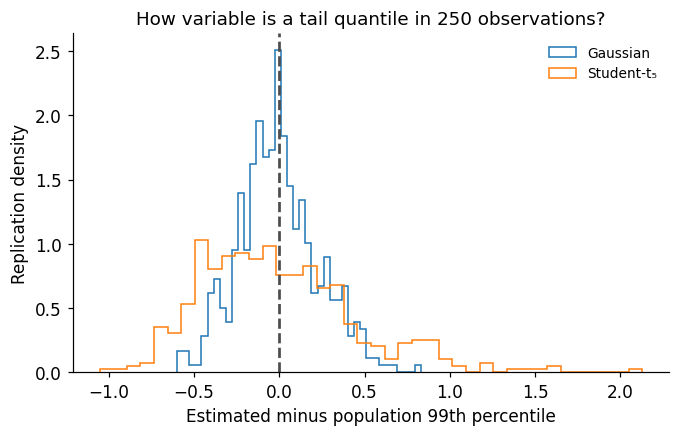

In [5]:
rng_quantiles = np.random.default_rng(405)
quantile_rows, tail_errors = [], {}
for name, distribution in populations.items():
    draws = distribution.rvs(size=(500, 250), random_state=rng_quantiles)
    for q in (.5, .95, .99):
        estimates = np.array([empirical_quantile(row, q) for row in draws])
        truth = distribution.ppf(q)
        quantile_rows.append({"population": name, "q": q, "true quantile": truth,
                              "mean estimate": estimates.mean(), "replication SD": estimates.std(ddof=1)})
        if q == .99:
            tail_errors[name] = estimates-truth
    
display(pd.DataFrame(quantile_rows).round(4))
fig, ax = plt.subplots()
for name, errors in tail_errors.items():
    ax.hist(errors, bins=40, density=True, histtype="step", label=name)
ax.axvline(0, color="0.3", linestyle="--")
ax.set(xlabel="Estimated minus population 99th percentile", ylabel="Replication density",
       title="How variable is a tail quantile in 250 observations?")
ax.legend(fontsize=9)
plt.show()

## 4. Histograms and kernel density estimation

A histogram divides the observation range into bins. Its shape changes with the bin boundaries and widths. A kernel density estimate (KDE) instead places a smooth density around each observation:
$$\hat f_h(x)=\frac1{nh}\sum_i K\left(\frac{x-X_i}{h}\right),\qquad h>0.$$
The kernel integrates to one. With a Gaussian kernel, $K=\phi$. The bandwidth $h$ controls how strongly the observations are smoothed. A small bandwidth preserves local fluctuations, while a large one can hide features of the population.

For illustration, I draw 250 iid observations from $0.6N(-1,0.5^2)+0.4N(1.5,0.7^2)$ using seed 406. Its known density has two groups. I compare Gaussian KDE bandwidths at 0.1, 1, and 100 times the default Scott factor, retaining the course's small/default/large comparison. The default differs from R's bandwidth rule.

Multiplier 0.1: bandwidth 0.0440


Multiplier 1: bandwidth 0.4401
Multiplier 100: bandwidth 44.0143


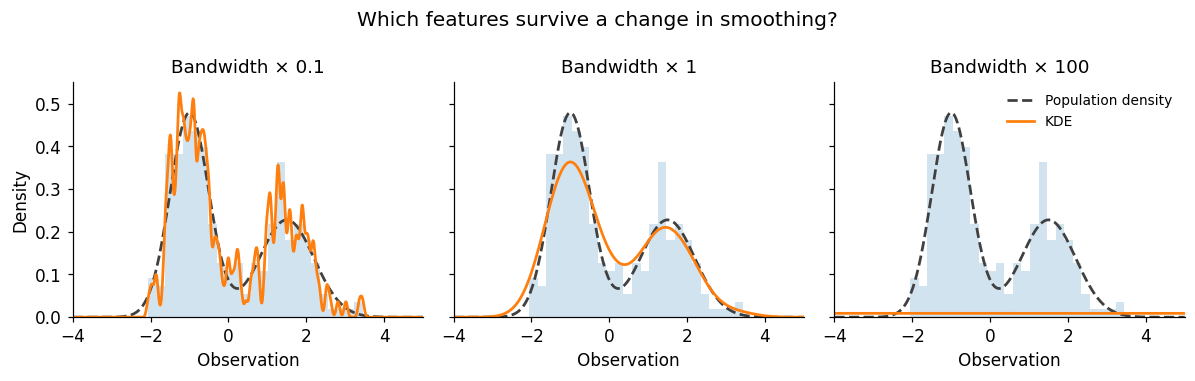

In [6]:
rng_kde = np.random.default_rng(406)
components = rng_kde.random(250) < .6
mixture_sample = rng_kde.normal(np.where(components, -1, 1.5), np.where(components, .5, .7))
kde_grid = np.linspace(-4, 5, 801)
mixture_density = .6*stats.norm.pdf(kde_grid, loc=-1, scale=.5)+.4*stats.norm.pdf(kde_grid, loc=1.5, scale=.7)
default_kde = stats.gaussian_kde(mixture_sample)
fig, axes = plt.subplots(1, 3, figsize=(11, 3.5), sharex=True, sharey=True)
for ax, multiplier in zip(axes, (.1, 1, 100)):
    kde = stats.gaussian_kde(mixture_sample, bw_method=default_kde.factor*multiplier)
    ax.hist(mixture_sample, bins=25, density=True, alpha=.2)
    ax.plot(kde_grid, mixture_density, "--", color="0.25", label="Population density")
    ax.plot(kde_grid, kde(kde_grid), color="C1", label="KDE")
    ax.set(xlabel="Observation", title=f"Bandwidth × {multiplier:g}", xlim=(-4, 5))
    print(f"Multiplier {multiplier:g}: bandwidth {np.sqrt(kde.covariance[0,0]):.4f}")
axes[0].set_ylabel("Density")
axes[-1].legend(fontsize=9)
fig.suptitle("Which features survive a change in smoothing?")
fig.tight_layout()
plt.show()

The smallest bandwidth produces peaks tied closely to individual observations. The largest smooths away both population groups. Neither local fluctuations nor an exceptionally smooth curve should be treated as evidence of the true shape. A KDE also does not reveal unobserved extreme outcomes reliably.

## 5. Quantile–quantile plots

A QQ plot compares ordered observations with quantiles of a reference distribution. I use plotting probabilities $q_i=(i-0.5)/n$:
$$\left(F_0^{-1}(q_i),X_{(i)}\right).$$
If population and reference agree, the points should lie approximately on the identity line. A location–scale transformation gives a straight line with intercept and slope reflecting those parameters. Systematic curvature suggests a shape difference, although tail points can fluctuate substantially in a finite sample. This is a descriptive comparison, not a hypothesis test.

For illustration, I generate 1,000 iid Gaussian and unit-variance Student-$t_5$ observations using seed 408. I compare both with a Gaussian reference, then the Student-t sample with its correct reference.

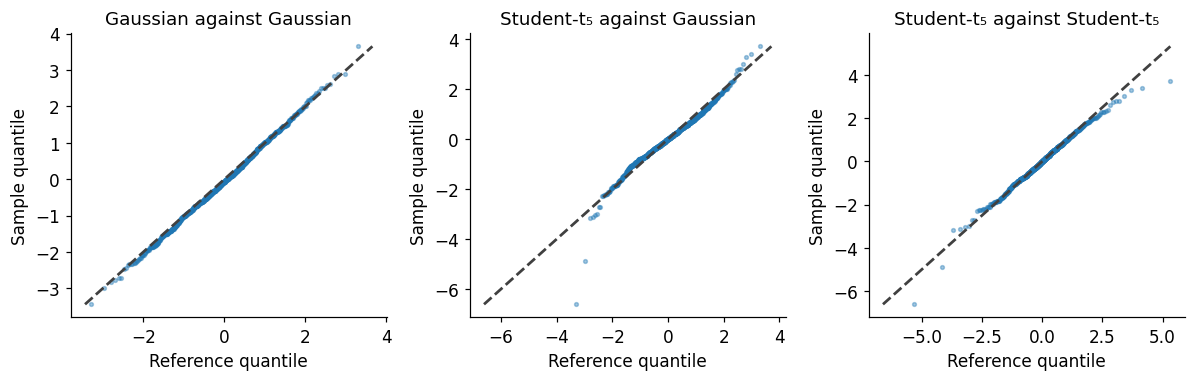

In [7]:
rng_qq = np.random.default_rng(408)
gaussian_sample = rng_qq.normal(size=1000)
t_sample = stats.t.rvs(5, scale=np.sqrt(3/5), size=1000, random_state=rng_qq)
comparisons = [("Gaussian against Gaussian", gaussian_sample, stats.norm()),
               ("Student-t₅ against Gaussian", t_sample, stats.norm()),
               ("Student-t₅ against Student-t₅", t_sample, populations["Student-t₅"])]
fig, axes = plt.subplots(1, 3, figsize=(11, 3.6))
for ax, (name, values, reference) in zip(axes, comparisons):
    theoretical, observed = qq_data(values, reference)
    ax.scatter(theoretical, observed, s=6, alpha=.4)
    limits = [min(theoretical.min(), observed.min()), max(theoretical.max(), observed.max())]
    ax.plot(limits, limits, "--", color="0.25")
    ax.set(xlabel="Reference quantile", ylabel="Sample quantile", title=name)
fig.tight_layout()
plt.show()

## 6. What the methods reveal

The ECDF estimates cumulative probabilities, empirical quantiles locate probability thresholds, and KDE describes a smoothed density. QQ plots compare a sample with a chosen reference. These objects answer different questions and should not be treated as interchangeable estimates of shape.

The known populations make their limitations visible. A small sample gives an uneven distribution estimate, tail quantiles depend on relatively few observations, and smoothing choices affect the apparent density. None of these methods identifies an unknown financial distribution with certainty.